In [1]:
# Imports
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import umap

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PLOTLY_TEMPLATE = "plotly_white"

ROOT = Path().resolve().parents[1] if "__file__" not in dir() else Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data" / "match_data"


In [2]:
# ── Champion Class Mapping ────────────────────────────────────────────────────

_RAW = {
    # Assassin
    "Akali": "Assassin", "Diana": "Assassin", "Ekko": "Assassin",
    "Evelynn": "Assassin", "Fizz": "Assassin", "Kassadin": "Assassin",
    "Katarina": "Assassin", "Kha'Zix": "Assassin", "Naafiri": "Assassin",
    "Nocturne": "Assassin", "Pyke": "Assassin", "Qiyana": "Assassin",
    "Rengar": "Assassin", "Shaco": "Assassin", "Talon": "Assassin",
    "Zed": "Assassin",

    # Skirmisher
    "Bel'Veth": "Skirmisher", "Fiora": "Skirmisher", "Gwen": "Skirmisher",
    "Jax": "Skirmisher", "Kayn": "Skirmisher", "Kled": "Skirmisher",
    "Lillia": "Skirmisher", "Master Yi": "Skirmisher", "Nilah": "Skirmisher",
    "Riven": "Skirmisher", "Tryndamere": "Skirmisher", "Viego": "Skirmisher",
    "Yasuo": "Skirmisher", "Yone": "Skirmisher", "Zaahen": "Skirmisher",

    # Juggernaut
    "Aatrox": "Juggernaut", "Darius": "Juggernaut", "Dr. Mundo": "Juggernaut",
    "Garen": "Juggernaut", "Illaoi": "Juggernaut", "Mordekaiser": "Juggernaut",
    "Nasus": "Juggernaut", "Sett": "Juggernaut", "Shyvana": "Juggernaut",
    "Trundle": "Juggernaut", "Udyr": "Juggernaut", "Urgot": "Juggernaut",
    "Volibear": "Juggernaut", "Yorick": "Juggernaut",

    # Diver
    "Ambessa": "Diver", "Briar": "Diver", "Camille": "Diver",
    "Elise": "Diver", "Hecarim": "Diver", "Irelia": "Diver",
    "Jarvan IV": "Diver", "Lee Sin": "Diver", "Olaf": "Diver",
    "Pantheon": "Diver", "Rek'Sai": "Diver", "Renekton": "Diver",
    "Skarner": "Diver", "Vi": "Diver", "Warwick": "Diver",
    "Wukong": "Diver", "Xin Zhao": "Diver",

    # Battlemage
    "Anivia": "Battlemage", "Aurelion Sol": "Battlemage", "Aurora": "Battlemage",
    "Cassiopeia": "Battlemage", "Karthus": "Battlemage", "Malzahar": "Battlemage",
    "Rumble": "Battlemage", "Ryze": "Battlemage", "Swain": "Battlemage",
    "Taliyah": "Battlemage", "Viktor": "Battlemage", "Vladimir": "Battlemage",

    # Burst
    "Ahri": "Burst", "Annie": "Burst", "Brand": "Burst",
    "Karma": "Burst", "LeBlanc": "Burst", "Lissandra": "Burst",
    "Neeko": "Burst", "Orianna": "Burst", "Seraphine": "Burst",
    "Sylas": "Burst", "Syndra": "Burst", "Twisted Fate": "Burst",
    "Veigar": "Burst", "Vex": "Burst", "Zoe": "Burst",

    # Artillery
    "Hwei": "Artillery", "Jayce": "Artillery", "Lux": "Artillery",
    "Mel": "Artillery", "Vel'Koz": "Artillery", "Xerath": "Artillery",
    "Ziggs": "Artillery",

    # Enchanter
    "Janna": "Enchanter", "Lulu": "Enchanter", "Milio": "Enchanter",
    "Nami": "Enchanter", "Renata Glasc": "Enchanter", "Sona": "Enchanter",
    "Soraka": "Enchanter", "Taric": "Enchanter", "Yuumi": "Enchanter",

    # Catcher
    "Bard": "Catcher", "Blitzcrank": "Catcher", "Ivern": "Catcher",
    "Morgana": "Catcher", "Rakan": "Catcher", "Thresh": "Catcher",
    "Zyra": "Catcher",

    # Vanguard
    "Alistar": "Vanguard", "Amumu": "Vanguard", "Gragas": "Vanguard",
    "Leona": "Vanguard", "Malphite": "Vanguard", "Maokai": "Vanguard",
    "Nautilus": "Vanguard", "Nunu & Willump": "Vanguard", "Nunu": "Vanguard",
    "Ornn": "Vanguard", "Rammus": "Vanguard", "Rell": "Vanguard",
    "Sejuani": "Vanguard", "Sion": "Vanguard", "Zac": "Vanguard",

    # Warden
    "Braum": "Warden", "Galio": "Warden", "K'Sante": "Warden",
    "Poppy": "Warden", "Shen": "Warden", "Tahm Kench": "Warden",

    # Marksman
    "Akshan": "Marksman", "Aphelios": "Marksman", "Ashe": "Marksman",
    "Caitlyn": "Marksman", "Corki": "Marksman", "Draven": "Marksman",
    "Ezreal": "Marksman", "Jhin": "Marksman", "Jinx": "Marksman",
    "Kai'Sa": "Marksman", "Kalista": "Marksman", "Kindred": "Marksman",
    "Kog'Maw": "Marksman", "Lucian": "Marksman", "Miss Fortune": "Marksman",
    "Samira": "Marksman", "Senna": "Marksman", "Sivir": "Marksman",
    "Smolder": "Marksman", "Tristana": "Marksman", "Twitch": "Marksman",
    "Varus": "Marksman", "Vayne": "Marksman", "Xayah": "Marksman",
    "Yunara": "Marksman", "Zeri": "Marksman",

    # Specialist
    "Azir": "Specialist", "Cho'Gath": "Specialist", "Fiddlesticks": "Specialist",
    "Gangplank": "Specialist", "Gnar": "Specialist", "Graves": "Specialist",
    "Heimerdinger": "Specialist", "Kayle": "Specialist", "Kennen": "Specialist",
    "Nidalee": "Specialist", "Quinn": "Specialist", "Singed": "Specialist",
    "Teemo": "Specialist", "Zilean": "Specialist",
}

import re
def _norm(s):
    return re.sub(r"[^a-z]", "", s.lower())

_CLASS_LOOKUP = {_norm(k): v for k, v in _RAW.items()}

def get_class(champion_name):
    return _CLASS_LOOKUP.get(_norm(str(champion_name)), "Unknown")

CLASS_ORDER = [
    "Assassin", "Skirmisher", "Juggernaut", "Diver",
    "Battlemage", "Burst", "Artillery",
    "Enchanter", "Catcher",
    "Vanguard", "Warden",
    "Marksman", "Specialist", "Unknown",
]

print(f"Champion class mapping loaded ({len(_RAW)} champions defined).")
print("Sample:", {c: get_class(c) for c in ["Jinx", "MissFortune", "LeeSin", "Thresh", "Aatrox", "Sylas"]})


Champion class mapping loaded (173 champions defined).
Sample: {'Jinx': 'Marksman', 'MissFortune': 'Marksman', 'LeeSin': 'Diver', 'Thresh': 'Catcher', 'Aatrox': 'Juggernaut', 'Sylas': 'Burst'}


In [3]:
# ── 1. Data Preparation ───────────────────────────────────────────────────────

# Load most recent CSV from match_data/
csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")
csv_path = csv_files[-1]
print(f"Loading: {csv_path}")
raw = pd.read_csv(csv_path)
print(f"Raw shape: {raw.shape}")

# Filter: drop remakes (champLevel < 3)
df = raw.dropna(subset=["win", "championName"]).copy()
df = df[df["champLevel"] >= 3]
df["win"] = df["win"].astype(int)

# ── Derived features ──────────────────────────────────────────────────────────
df["nonCsGold"]        = df["goldEarned"] - (df["totalMinionsKilled"] + df["neutralMinionsKilled"]) * 20
df["damageEfficiency"] = df["totalDamageToChampions"] / df["goldEarned"].replace(0, 1)
df["mitigationRatio"]  = df["damageSelfMitigated"] / (df["totalDamageTaken"] + df["damageSelfMitigated"]).replace(0, 1)

# Damage type ratio: 1.0 = pure physical, 0.0 = pure magic
# Separates ADCs/assassins from mages/AP champions within the same role
df["physicalDamageRatio"] = df["physicalDamageToChampions"] / df["totalDamageToChampions"].replace(0, 1)

# Assist ratio: how team-reliant is your contribution?
# High for enchanters/tanks (enable kills), low for carries (finish kills)
df["assistRatio"] = df["assists"] / (df["kills"] + df["assists"] + 1)

FEATURES = [
    # Combat — split by damage type instead of total
    # (totalDamageToChampions dropped: it's the sum of the two below)
    "kills", "deaths", "assists", "kda",
    "physicalDamageToChampions", "magicDamageToChampions",
    "totalDamageTaken", "damageSelfMitigated",
    "damageToBuildings", "damageToObjectives",
    # Economy
    "goldEarned", "totalMinionsKilled", "neutralMinionsKilled",
    # Vision — visionScore dropped: it's a composite of the three below
    "wardsPlaced", "wardsKilled", "visionWardsBought",
    # CC / utility
    "timeCCingOthers", "totalTimeCCDealt",
    # Structures / objectives
    "turretKills",
    # Survival
    "champLevel", "totalTimeSpentDead", "longestTimeSpentLiving",
    # Derived
    "nonCsGold", "damageEfficiency", "mitigationRatio",
    "physicalDamageRatio", "assistRatio",
]
TARGET = "win"

# Primary role per champion = most common teamPosition in the dataset
role_map = (
    df[df["teamPosition"].notna() & (df["teamPosition"] != "")]
    .groupby("championName")["teamPosition"]
    .agg(lambda x: x.value_counts().index[0])
)

df = df.dropna(subset=[TARGET] + FEATURES)

print(f"After filtering: {df.shape}")
print(f"Win rate: {df[TARGET].mean():.3f}")
print(f"Unique champions: {df['championName'].nunique()}")
print(f"Features: {len(FEATURES)}")
print(f"Role map sample: {dict(list(role_map.items())[:6])}")


Loading: C:\Users\Laser\data\match_data\challenger_matches.csv
Raw shape: (372861, 51)
After filtering: (370163, 56)
Win rate: 0.500
Unique champions: 172
Features: 27
Role map sample: {'Aatrox': 'TOP', 'Ahri': 'MIDDLE', 'Akali': 'MIDDLE', 'Akshan': 'MIDDLE', 'Alistar': 'UTILITY', 'Ambessa': 'TOP'}


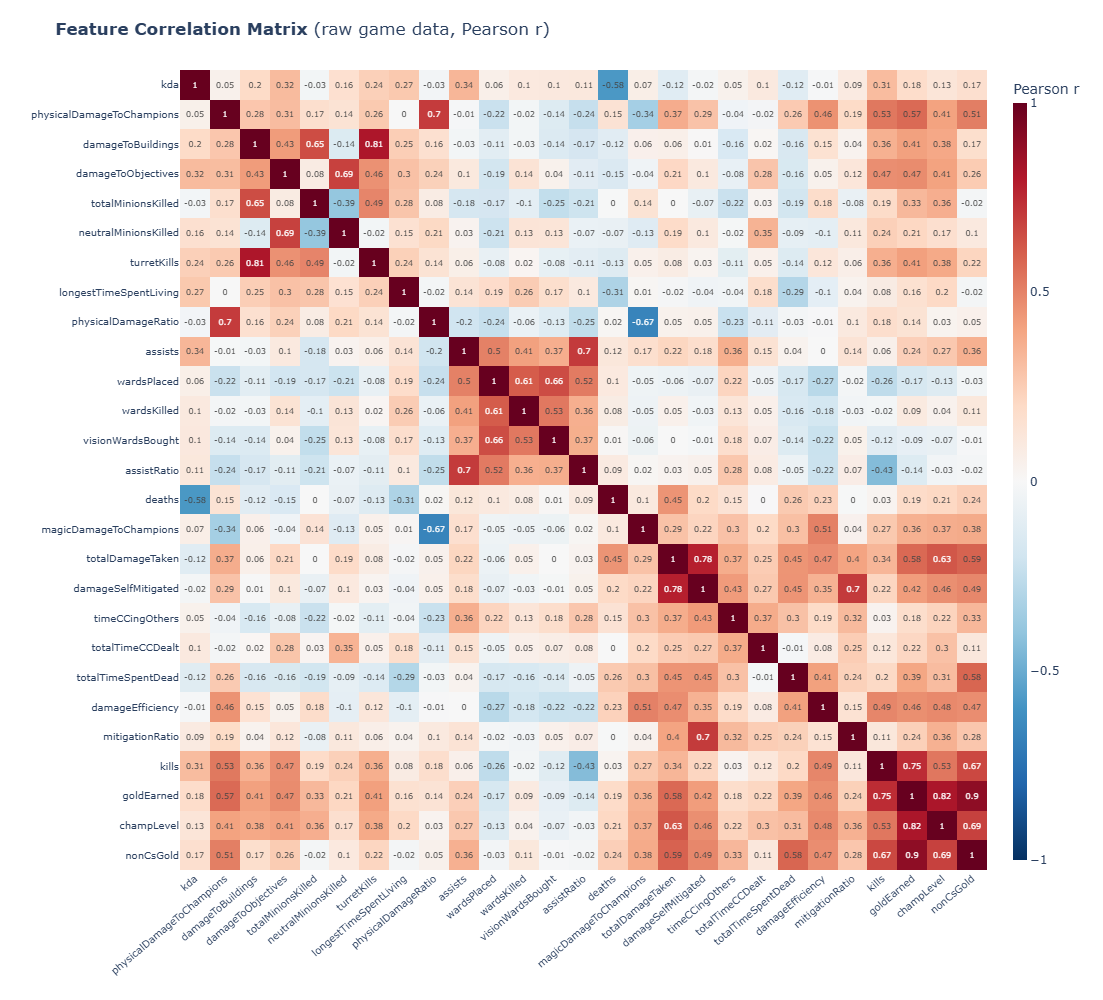

In [25]:
# ── Feature Correlation Matrix ────────────────────────────────────────────────
# Pearson correlations between raw features across all games.
# Shows which stats move together — explains why some model coefficients
# are unstable and why PDP would be misleading for correlated pairs.

feat_corr = df[FEATURES].corr(method="pearson")

# Order features by hierarchical clustering for better visual grouping
_agg = AgglomerativeClustering(n_clusters=min(4, len(FEATURES)), linkage="ward")
_feat_cluster = _agg.fit_predict(feat_corr.values)
_feat_order = []
for cid in range(min(4, len(FEATURES))):
    _feat_order.extend(np.where(_feat_cluster == cid)[0])
feat_names_ordered = [FEATURES[i] for i in _feat_order]
corr_ordered = feat_corr.loc[feat_names_ordered, feat_names_ordered]

fig = go.Figure(go.Heatmap(
    z=corr_ordered.values,
    x=feat_names_ordered,
    y=feat_names_ordered,
    colorscale="RdBu_r",
    zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title="Pearson r", thickness=14),
    text=corr_ordered.round(2).values,
    texttemplate="%{text}",
    textfont=dict(size=8),
    hovertemplate="%{y} × %{x}: %{z:.3f}<extra></extra>",
))
fig.update_layout(
    title=dict(text="<b>Feature Correlation Matrix</b> (raw game data, Pearson r)", font_size=17),
    xaxis=dict(tickangle=-40, tickfont=dict(size=10)),
    yaxis=dict(autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    height=1000,
    margin=dict(l=180, r=60, t=70, b=130),
)
fig.show()


In [5]:
# ── 2 & 3. Champion-Specific Logistic Regression ─────────────────────────────
# Train one logistic regression per champion.
# Features are standardized per-champion so coefficients are comparable.

MIN_SAMPLES = 1000   # skip champions with fewer games than this

scaler_map = {}     # champion -> fitted StandardScaler
model_map  = {}     # champion -> fitted LogisticRegression
coef_map   = {}     # champion -> coefficient Series (index = feature names)
metrics_map = {}    # champion -> {"accuracy": ..., "auc": ...}

champion_groups = df.groupby("championName")

for champ, group in champion_groups:
    if len(group) < MIN_SAMPLES:
        continue

    X = group[FEATURES].values
    y = group[TARGET].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit logistic regression
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs")
    model.fit(X_scaled, y)

    # Store
    scaler_map[champ] = scaler
    model_map[champ]  = model
    coef_map[champ]   = pd.Series(model.coef_[0], index=FEATURES)

    y_pred      = model.predict(X_scaled)
    y_prob      = model.predict_proba(X_scaled)[:, 1]
    metrics_map[champ] = {
        "n_games":  len(group),
        "accuracy": accuracy_score(y, y_pred),
        "auc":      roc_auc_score(y, y_prob) if len(np.unique(y)) > 1 else np.nan,
    }

print(f"Trained models for {len(model_map)} champions (≥{MIN_SAMPLES} games).")
metrics_df = pd.DataFrame(metrics_map).T.sort_values("auc", ascending=False)
print(metrics_df.head(10).to_string())


Trained models for 147 champions (≥1000 games).
          n_games  accuracy       auc
Belveth    1442.0  0.933426  0.983824
Kindred    1696.0  0.912736  0.973159
Hecarim    1755.0  0.917379  0.972240
JarvanIV   3733.0  0.911331  0.968802
Graves     4140.0  0.899758  0.965971
Nunu       1390.0  0.894964  0.965416
Yuumi      1174.0  0.907155  0.965346
XinZhao    2616.0  0.894113  0.965019
Ivern      1152.0  0.898438  0.964677
Vi         1984.0  0.895161  0.963057


In [6]:
# ── 4. Build Cross-Champion Coefficient Matrix ────────────────────────────────

coef_matrix = pd.DataFrame(coef_map).T   # shape: (num_champions, num_features)
coef_matrix = coef_matrix[FEATURES]      # enforce consistent column order
coef_matrix.dropna(how="any", inplace=True)

print(f"Coefficient matrix shape: {coef_matrix.shape}")
print(coef_matrix.describe().round(3).to_string())


Coefficient matrix shape: (147, 27)
         kills   deaths  assists      kda  physicalDamageToChampions  magicDamageToChampions  totalDamageTaken  damageSelfMitigated  damageToBuildings  damageToObjectives  goldEarned  totalMinionsKilled  neutralMinionsKilled  wardsPlaced  wardsKilled  visionWardsBought  timeCCingOthers  totalTimeCCDealt  turretKills  champLevel  totalTimeSpentDead  longestTimeSpentLiving  nonCsGold  damageEfficiency  mitigationRatio  physicalDamageRatio  assistRatio
count  147.000  147.000  147.000  147.000                    147.000                 147.000           147.000              147.000            147.000             147.000     147.000             147.000               147.000      147.000      147.000            147.000          147.000           147.000      147.000     147.000             147.000                 147.000    147.000           147.000          147.000              147.000      147.000
mean     0.280   -1.017    0.615    2.163               

In [7]:
# ── Champion Class Metadata ────────────────────────────────────────────────────
# SUPPORT_CLASSES is kept for visual annotation only (diamond markers in UMAP).
# All champions are clustered together — stratifying by Riot's class labels
# would impose prior knowledge and defeat the purpose of unsupervised discovery.
# If supports end up in their own cluster, that's a data-driven finding.

SUPPORT_CLASSES  = {"Enchanter", "Catcher", "Vanguard", "Warden"}
coef_matrix_full = coef_matrix.copy()   # alias kept for any downstream compat

print(f"Clustering all {len(coef_matrix)} champions together.")
print(f"SUPPORT_CLASSES kept for visual annotation only: {sorted(SUPPORT_CLASSES)}")


Clustering all 147 champions together.
SUPPORT_CLASSES kept for visual annotation only: ['Catcher', 'Enchanter', 'Vanguard', 'Warden']


In [8]:
# ── Feature Selection — Genetic Algorithm ─────────────────────────────────────
# Scoring: average silhouette across k=3..6 to avoid biasing toward the
# trivial k=2 tank/non-tank split.

K_EVAL    = range(3, 7)
RANDOM_STATE_FS = RANDOM_STATE
np.random.seed(RANDOM_STATE_FS)

def _best_sil(X):
    """Score a feature subset: average silhouette over K_EVAL."""
    scores = {}
    for k in K_EVAL:
        if k >= X.shape[0]:
            break
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE_FS, n_init=10).fit_predict(X)
        scores[k] = silhouette_score(X, labels)
    if not scores:
        return -1.0, 3
    return float(np.mean(list(scores.values()))), max(scores, key=scores.get)

# ── Genetic Algorithm ──────────────────────────────────────────────────────────
POP_SIZE      = 50
N_GENERATIONS = 25
MUTATION_RATE = 0.08
MIN_FEAT_GA   = 3   # allow sparse solutions; GA will find the right floor

def _ga_fitness(ind):
    feats = [FEATURES[i] for i, b in enumerate(ind) if b]
    if len(feats) < 2:
        return -1.0
    s, _ = _best_sil(coef_matrix[feats].values)
    return s

def _crossover(p1, p2):
    pt = np.random.randint(1, len(FEATURES))
    return np.concatenate([p1[:pt], p2[pt:]])

def _mutate(ind):
    ind = ind.copy()
    flip = np.random.random(len(ind)) < MUTATION_RATE
    ind[flip] = 1 - ind[flip]
    while ind.sum() < MIN_FEAT_GA:
        ind[np.random.randint(len(ind))] = 1
    return ind

def _rand_individual():
    while True:
        ind = np.random.binomial(1, 0.5, len(FEATURES)).astype(int)
        if ind.sum() >= MIN_FEAT_GA:
            return ind

population = [_rand_individual() for _ in range(POP_SIZE)]

best_ever_ind = None
best_ever_fit = -1
gen_best_hist = []

print(f"Evolving {POP_SIZE} individuals × {N_GENERATIONS} generations...")
for gen in range(N_GENERATIONS):
    scores = [_ga_fitness(ind) for ind in population]

    gen_best     = max(scores)
    gen_best_ind = population[np.argmax(scores)]
    if gen_best > best_ever_fit:
        best_ever_fit = gen_best
        best_ever_ind = gen_best_ind.copy()

    gen_best_hist.append(gen_best)
    print(f"  Gen {gen+1:2d}: best={gen_best:.4f}  mean={np.mean(scores):.4f}  n_feat={int(gen_best_ind.sum())}")

    selected = []
    for _ in range(POP_SIZE):
        i, j = np.random.choice(POP_SIZE, 2, replace=False)
        selected.append(population[i] if scores[i] >= scores[j] else population[j])

    offspring = [best_ever_ind.copy()]
    for i in range(0, POP_SIZE - 1, 2):
        c1 = _mutate(_crossover(selected[i], selected[i + 1]))
        c2 = _mutate(_crossover(selected[i + 1], selected[i]))
        offspring.extend([c1, c2])
    population = offspring[:POP_SIZE]

CLUSTER_FEATURES = [FEATURES[i] for i, b in enumerate(best_ever_ind) if b]
print(f"\nGA best: {len(CLUSTER_FEATURES)} features  silhouette={best_ever_fit:.4f}")
print(f"CLUSTER_FEATURES = {CLUSTER_FEATURES}")

# ── Convergence plot ───────────────────────────────────────────────────────────
fig = go.Figure(go.Scatter(
    x=list(range(1, N_GENERATIONS + 1)),
    y=gen_best_hist,
    mode="lines+markers",
    marker=dict(size=7, color="steelblue"),
    line=dict(color="steelblue", width=2),
    hovertemplate="Gen %{x}: best sil=%{y:.4f}<extra></extra>",
))
fig.update_layout(
    title=dict(text="<b>GA Convergence</b> — Best Silhouette per Generation", font_size=17),
    xaxis_title="Generation",
    yaxis_title="Best Silhouette Score",
    template=PLOTLY_TEMPLATE,
    height=360,
    margin=dict(l=60, r=40, t=70, b=50),
)
fig.show()


Evolving 50 individuals × 25 generations...
  Gen  1: best=0.1775  mean=0.1424  n_feat=10
  Gen  2: best=0.1874  mean=0.1484  n_feat=7
  Gen  3: best=0.2089  mean=0.1544  n_feat=6
  Gen  4: best=0.2089  mean=0.1533  n_feat=6
  Gen  5: best=0.2155  mean=0.1621  n_feat=6
  Gen  6: best=0.2289  mean=0.1678  n_feat=5
  Gen  7: best=0.2499  mean=0.1681  n_feat=5
  Gen  8: best=0.2593  mean=0.1810  n_feat=4
  Gen  9: best=0.2593  mean=0.1825  n_feat=4
  Gen 10: best=0.2646  mean=0.1876  n_feat=5
  Gen 11: best=0.2713  mean=0.1912  n_feat=5
  Gen 12: best=0.3057  mean=0.1916  n_feat=3
  Gen 13: best=0.3141  mean=0.1960  n_feat=3
  Gen 14: best=0.3350  mean=0.2077  n_feat=4
  Gen 15: best=0.3350  mean=0.2055  n_feat=4
  Gen 16: best=0.3589  mean=0.2087  n_feat=3
  Gen 17: best=0.3589  mean=0.2065  n_feat=3
  Gen 18: best=0.3589  mean=0.2066  n_feat=3
  Gen 19: best=0.3589  mean=0.2107  n_feat=3
  Gen 20: best=0.3589  mean=0.2185  n_feat=3
  Gen 21: best=0.3639  mean=0.2206  n_feat=3
  Gen 22: 

In [9]:
# ── Alternative Clustering Approaches ─────────────────────────────────────────
# Shows why supports were excluded (baseline all-champs vs non-support),
# then compares strategies *within* the non-support set.

champs_carry = coef_matrix.index.tolist()          # already filtered (non-support)
champs_full  = coef_matrix_full.index.tolist()     # all champions including supports

M_carry = coef_matrix[CLUSTER_FEATURES].values
M_full  = coef_matrix_full[CLUSTER_FEATURES].values

def _run_clustering(M, champs, label):
    scores = {}
    for k in range(2, 9):
        if k >= len(champs): break
        lbls = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(M)
        scores[k] = silhouette_score(M, lbls)
    best_k = max(scores, key=scores.get)
    best_labels = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(M)
    print(f"\n{label}")
    print(f"  n={len(champs)}  best_k={best_k}  silhouette={scores[best_k]:.4f}")
    print(f"  Cluster sizes: {pd.Series(best_labels).value_counts().sort_index().to_dict()}")
    return best_k, scores[best_k], best_labels, scores

# ── All champions (shows why we split out supports) ───────────────────────────
k_full, sil_full, labels_full, _ = _run_clustering(M_full, champs_full, "All champions (includes supports)")

# ── Non-support baseline ──────────────────────────────────────────────────────
k_carry, sil_carry, labels_carry, _ = _run_clustering(M_carry, champs_carry, "Non-support baseline (current pipeline)")

crosstab_carry = pd.crosstab(
    pd.Series([get_class(c) for c in champs_carry], name="class"),
    pd.Series(labels_carry, name="cluster"),
)
print(crosstab_carry.to_string())

# ── B: Residualize PC1 within non-supports ────────────────────────────────────
pca1 = PCA(n_components=1, random_state=RANDOM_STATE)
pc1_proj = pca1.fit_transform(M_carry)
M_resid  = M_carry - pca1.inverse_transform(pc1_proj)
k_resid, sil_resid, labels_resid, _ = _run_clustering(M_resid, champs_carry, "B: Residualize dominant axis (within non-supports)")

crosstab_resid = pd.crosstab(
    pd.Series([get_class(c) for c in champs_carry], name="class"),
    pd.Series(labels_resid, name="cluster"),
)
print(crosstab_resid.to_string())

# ── C: Stratified — damage vs utility within non-supports ─────────────────────
UTILITY_CLASSES = {"Specialist"}   # adjust if needed
champs_dmg = [c for c in champs_carry if get_class(c) not in UTILITY_CLASSES]
champs_utl = [c for c in champs_carry if get_class(c) in UTILITY_CLASSES]
M_dmg = coef_matrix.loc[champs_dmg, CLUSTER_FEATURES].values

k_dmg, sil_dmg, labels_dmg, _ = _run_clustering(M_dmg, champs_dmg, "C: Damage-focused carries only")
sil_c = sil_dmg   # simplified — utility group too small to cluster meaningfully

# ── Summary plot ──────────────────────────────────────────────────────────────
labels_plot  = ["All champs<br>(incl. supports)", "Non-support<br>baseline", "B: Residualize<br>PC1", "C: Damage<br>carries only"]
sils         = [sil_full, sil_carry, sil_resid, sil_c]
ks           = [k_full,   k_carry,   k_resid,   k_dmg]
colors_bar   = ["lightgrey", "#5c85d6", "#e05c5c", "#5cb85c"]

fig = make_subplots(rows=1, cols=2, subplot_titles=["Silhouette Score", "Best k"])
fig.add_trace(go.Bar(x=labels_plot, y=sils, marker_color=colors_bar, showlegend=False,
                     hovertemplate="%{x}<br>Silhouette: %{y:.4f}<extra></extra>"), row=1, col=1)
fig.add_trace(go.Bar(x=labels_plot, y=ks, marker_color=colors_bar, showlegend=False,
                     hovertemplate="%{x}<br>k=%{y}<extra></extra>"), row=1, col=2)
fig.update_layout(
    title=dict(text="<b>Clustering Approach Comparison</b>", font_size=17),
    template=PLOTLY_TEMPLATE, height=400,
    margin=dict(l=60, r=40, t=100, b=80),
)
fig.show()

print("\n── Verdict ──────────────────────────────────────────────────────────")
best_sil = max(zip(labels_plot, sils), key=lambda x: x[1])
most_k   = max(zip(labels_plot, ks),   key=lambda x: x[1])
print(f"  Highest silhouette: {best_sil[0].replace('<br>', ' ')} ({best_sil[1]:.4f})")
print(f"  Most clusters:      {most_k[0].replace('<br>', ' ')} (k={most_k[1]})")



All champions (includes supports)
  n=147  best_k=2  silhouette=0.4934
  Cluster sizes: {0: 87, 1: 60}

Non-support baseline (current pipeline)
  n=147  best_k=2  silhouette=0.4934
  Cluster sizes: {0: 87, 1: 60}
cluster      0   1
class             
Artillery    6   1
Assassin     4  11
Battlemage   8   3
Burst       13   1
Catcher      4   3
Diver        4  10
Enchanter    7   0
Juggernaut   2   7
Marksman    20   2
Skirmisher   4   8
Specialist   7   5
Unknown      0   1
Vanguard     5   6
Warden       3   2

B: Residualize dominant axis (within non-supports)
  n=147  best_k=2  silhouette=0.4779
  Cluster sizes: {0: 37, 1: 110}
cluster     0   1
class            
Artillery   1   6
Assassin    2  13
Battlemage  1  10
Burst       5   9
Catcher     6   1
Diver       0  14
Enchanter   7   0
Juggernaut  2   7
Marksman    1  21
Skirmisher  3   9
Specialist  1  11
Unknown     0   1
Vanguard    6   5
Warden      2   3

C: Damage-focused carries only
  n=135  best_k=2  silhouette=0.4980
  C


── Verdict ──────────────────────────────────────────────────────────
  Highest silhouette: C: Damage carries only (0.4980)
  Most clusters:      All champs (incl. supports) (k=2)


In [10]:
# ── Clustering + k Selection ──────────────────────────────────────────────────
# Features were selected to maximise avg silhouette over k=3..6 (not k=2),
# so clustering is now a separate decision. Inspect the elbow + silhouette
# plot below and set CHOSEN_K. None = auto (silhouette winner across 2..6).

CHOSEN_K = 4   # ← set after inspecting the plot; None = auto

M = coef_matrix[CLUSTER_FEATURES].values
K_RANGE = range(2, 11)

inertias, sil_scores = {}, {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(M)
    inertias[k]   = km.inertia_
    sil_scores[k] = silhouette_score(M, labels)
    print(f"  k={k}  silhouette={sil_scores[k]:.4f}  inertia={inertias[k]:,.0f}")

# ── Elbow + Silhouette plot ────────────────────────────────────────────────────
ks = list(K_RANGE)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ks, y=[sil_scores[k] for k in ks],
    mode="lines+markers", name="Silhouette",
    marker=dict(size=10, color="steelblue"),
    line=dict(color="steelblue", width=2),
    hovertemplate="k=%{x}  silhouette=%{y:.4f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=ks, y=[inertias[k] for k in ks],
    mode="lines+markers", name="Inertia (elbow)",
    marker=dict(size=10, color="tomato"),
    line=dict(color="tomato", width=2, dash="dash"),
    yaxis="y2",
    hovertemplate="k=%{x}  inertia=%{y:,.0f}<extra></extra>",
))

fig.update_layout(
    title=dict(text="<b>k Selection</b> — Silhouette & Elbow (k=2..6)", font_size=17),
    xaxis=dict(title="Number of clusters (k)", tickmode="linear", dtick=1),
    yaxis=dict(title="Silhouette Score", color="steelblue"),
    yaxis2=dict(title="Inertia", overlaying="y", side="right", color="tomato"),
    template=PLOTLY_TEMPLATE, height=380,
    margin=dict(l=70, r=90, t=70, b=60),
    legend=dict(x=0.01, y=0.99),
)
fig.show()

# ── Fit final clustering ───────────────────────────────────────────────────────
best_k_auto = max(sil_scores, key=sil_scores.get)
best_k      = CHOSEN_K if CHOSEN_K is not None else best_k_auto

if CHOSEN_K is not None:
    print(f"\nUsing CHOSEN_K={best_k}  (silhouette winner was k={best_k_auto})")
else:
    print(f"\nAuto-selected k={best_k} (highest silhouette)")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(M)

coef_matrix["cluster"] = cluster_labels
print("\nChampions per cluster:")
print(coef_matrix["cluster"].value_counts().sort_index().to_string())
print(f"\n→ Change CHOSEN_K to override (currently {CHOSEN_K})")


  k=2  silhouette=0.4934  inertia=14
  k=3  silhouette=0.4227  inertia=10
  k=4  silhouette=0.3947  inertia=7
  k=5  silhouette=0.3633  inertia=6
  k=6  silhouette=0.3217  inertia=5
  k=7  silhouette=0.3117  inertia=5
  k=8  silhouette=0.2985  inertia=4
  k=9  silhouette=0.2977  inertia=4
  k=10  silhouette=0.2684  inertia=3



Using CHOSEN_K=4  (silhouette winner was k=2)

Champions per cluster:
cluster
0    22
1    34
2    33
3    58

→ Change CHOSEN_K to override (currently 4)


In [11]:
# ── Unified Cluster Labels + Color Mapping ────────────────────────────────────
# All champions are in coef_matrix. Build a consistent label/color scheme
# used by all downstream plots.

cluster_label_map = {
    champ: f"Cluster {int(coef_matrix.loc[champ, 'cluster'])}"
    for champ in coef_matrix.index
}

all_labels  = [f"Cluster {i}" for i in range(best_k)]
palette     = px.colors.qualitative.Plotly + px.colors.qualitative.Dark24
label_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}

# Annotated matrix for downstream cells
coef_matrix_combined = coef_matrix.copy()
coef_matrix_combined["cluster_label"] = [cluster_label_map[c] for c in coef_matrix.index]
coef_matrix_combined["group"] = [
    "Support" if get_class(c) in SUPPORT_CLASSES else "Carry"
    for c in coef_matrix.index
]

print("Cluster sizes:")
print(coef_matrix_combined["cluster_label"].value_counts().sort_index().to_string())
print("\nClass breakdown per cluster:")
for lbl in all_labels:
    sub = coef_matrix_combined[coef_matrix_combined["cluster_label"] == lbl]
    classes = pd.Series([get_class(c) for c in sub.index]).value_counts().head(6)
    print(f"  {lbl} (n={len(sub)}): {dict(classes)}")


Cluster sizes:
cluster_label
Cluster 0    22
Cluster 1    34
Cluster 2    33
Cluster 3    58

Class breakdown per cluster:
  Cluster 0 (n=22): {'Enchanter': np.int64(7), 'Catcher': np.int64(4), 'Vanguard': np.int64(3), 'Burst': np.int64(2), 'Battlemage': np.int64(1), 'Warden': np.int64(1)}
  Cluster 1 (n=34): {'Skirmisher': np.int64(7), 'Assassin': np.int64(6), 'Diver': np.int64(4), 'Burst': np.int64(3), 'Juggernaut': np.int64(3), 'Specialist': np.int64(3)}
  Cluster 2 (n=33): {'Diver': np.int64(7), 'Vanguard': np.int64(5), 'Assassin': np.int64(5), 'Juggernaut': np.int64(4), 'Specialist': np.int64(2), 'Catcher': np.int64(2)}
  Cluster 3 (n=58): {'Marksman': np.int64(19), 'Burst': np.int64(8), 'Battlemage': np.int64(7), 'Specialist': np.int64(6), 'Artillery': np.int64(5), 'Assassin': np.int64(3)}


In [12]:
# ── Within-Role Surprise Analysis ─────────────────────────────────────────────
# For each champion, compare their full coefficient vector to the average for
# their role (TOP/JUNGLE/MIDDLE/BOTTOM/UTILITY). Large z-scores = win conditions
# that are unusual for that role → the "surprising" cases.
#
# Uses ALL features (not just CLUSTER_FEATURES) so nothing is hidden.

full_coefs = pd.DataFrame(coef_map).T[FEATURES].copy()
full_coefs["role"] = full_coefs.index.map(role_map)
full_coefs = full_coefs.dropna(subset=["role"])

role_means = full_coefs.groupby("role")[FEATURES].mean()
role_stds  = full_coefs.groupby("role")[FEATURES].std().replace(0, 1)

surprise_rows = []
for champ in full_coefs.index:
    role = full_coefs.loc[champ, "role"]
    coefs = full_coefs.loc[champ, FEATURES]
    z = (coefs - role_means.loc[role]) / role_stds.loc[role]
    top_feat  = z.abs().idxmax()
    surprise_rows.append({
        "champion":      champ,
        "role":          role,
        "cluster":       int(coef_matrix.loc[champ, "cluster"]) if champ in coef_matrix.index else -1,
        "top_feature":   top_feat,
        "z_score":       round(z[top_feat], 2),
        "coefficient":   round(coefs[top_feat], 3),
        "role_avg_coef": round(role_means.loc[role, top_feat], 3),
    })

surprises_df = (
    pd.DataFrame(surprise_rows)
    .sort_values("z_score", key=abs, ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most surprising champions (within-role):\n")
print(surprises_df.head(30).to_string(index=False))

# ── Heatmap: which roles have the most surprises? ─────────────────────────────
role_feat_counts = (
    surprises_df.groupby(["role", "top_feature"])
    .size()
    .unstack(fill_value=0)
)
print(f"\nSurprise feature distribution by role:\n{role_feat_counts.to_string()}")

# ── Interactive plot: z-score by champion, colored by role ────────────────────
top_n = 40
plot_df = surprises_df.head(top_n).sort_values("z_score")

role_colors = {
    "TOP": "steelblue", "JUNGLE": "forestgreen", "MIDDLE": "darkorange",
    "BOTTOM": "crimson", "UTILITY": "mediumpurple",
}

fig = go.Figure()
for role in plot_df["role"].unique():
    sub = plot_df[plot_df["role"] == role]
    fig.add_trace(go.Bar(
        y=sub["champion"],
        x=sub["z_score"],
        orientation="h",
        name=role,
        marker_color=role_colors.get(role, "grey"),
        customdata=sub[["top_feature", "coefficient", "role_avg_coef"]].values,
        hovertemplate=(
            "<b>%{y}</b> (%{fullData.name})<br>"
            "Feature: %{customdata[0]}<br>"
            "z-score: %{x:.2f}<br>"
            "Coef: %{customdata[1]:.3f}  (role avg: %{customdata[2]:.3f})"
            "<extra></extra>"
        ),
    ))

fig.add_vline(x=0, line_width=1, line_color="gray")
fig.update_layout(
    title=dict(text="<b>Within-Role Surprise Analysis</b> — Champions with Unusual Win Conditions", font_size=16),
    xaxis=dict(title="Z-score vs role average"),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    barmode="overlay",
    height=max(500, top_n * 20),
    margin=dict(l=140, r=60, t=70, b=50),
    legend=dict(title="Role", x=1.01, y=1),
)
fig.show()


Top 30 most surprising champions (within-role):

   champion    role  cluster               top_feature  z_score  coefficient  role_avg_coef
      Ziggs  BOTTOM        3               turretKills     4.36        1.980          0.623
      Elise UTILITY        2               turretKills     3.73        0.739          0.305
    DrMundo  JUNGLE        2               turretKills     3.31        1.079          0.397
    Chogath     TOP        2        damageToObjectives     3.30        1.738          0.795
AurelionSol  BOTTOM        3        totalTimeSpentDead     3.29        1.524          0.581
    Belveth  JUNGLE        1                     kills     3.21        1.163          0.257
      Braum UTILITY        0 physicalDamageToChampions     3.19        1.413          0.226
    Morgana UTILITY        1                   assists    -3.18       -0.095          0.966
      Brand  BOTTOM        1               wardsKilled    -3.15       -0.384         -0.038
       Fizz  MIDDLE        1   

In [13]:
# ── Representation Comparison: Coefficient Space vs Win-Delta Space ────────────
from sklearn.metrics import adjusted_rand_score

# ── Build win-delta matrix ─────────────────────────────────────────────────────
champs_in_model = coef_matrix.index.tolist()
delta_rows = {}
for champ in champs_in_model:
    sub    = df[df["championName"] == champ]
    wins   = sub[sub["win"] == True][FEATURES].mean()
    losses = sub[sub["win"] == False][FEATURES].mean()
    delta_rows[champ] = wins - losses

delta_matrix = pd.DataFrame(delta_rows).T.dropna()
common       = [c for c in champs_in_model if c in delta_matrix.index]
delta_matrix = delta_matrix.loc[common]

delta_scaled = pd.DataFrame(
    StandardScaler().fit_transform(delta_matrix[FEATURES]),
    index=common, columns=FEATURES,
)

D_delta = delta_scaled[CLUSTER_FEATURES].values
D_coef  = coef_matrix.loc[common, CLUSTER_FEATURES].values

# ── Cluster both at same k ─────────────────────────────────────────────────────
labels_delta = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(D_delta)
labels_coef  = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(D_coef)

# ── Metrics ────────────────────────────────────────────────────────────────────
sil_coef  = silhouette_score(D_coef,  labels_coef)
sil_delta = silhouette_score(D_delta, labels_delta)
ari       = adjusted_rand_score(labels_coef, labels_delta)

print(f"Silhouette — Coefficient space : {sil_coef:.4f}")
print(f"Silhouette — Win-delta space   : {sil_delta:.4f}")
print(f"Adjusted Rand Index (agreement): {ari:.4f}  (1=identical, 0=random)\n")

# ── Class composition per cluster ──────────────────────────────────────────────
comp_df = pd.DataFrame({
    "champion": common,
    "class":    [get_class(c) for c in common],
    "coef_cl":  labels_coef,
    "delta_cl": labels_delta,
}).set_index("champion")
comp_df["agrees"] = comp_df["coef_cl"] == comp_df["delta_cl"]
print(f"Champion-level agreement: {comp_df['agrees'].mean():.1%}  ({comp_df['agrees'].sum()}/{len(comp_df)})\n")

for rep, col in [("Coefficient", "coef_cl"), ("Win-delta", "delta_cl")]:
    print(f"── {rep} clusters ──")
    for k in range(best_k):
        sub = comp_df[comp_df[col] == k]
        top = pd.Series([get_class(c) for c in sub.index]).value_counts().head(4)
        print(f"  Cluster {k} (n={len(sub)}): {dict(top)}")
    print()

disagree = comp_df[~comp_df["agrees"]].sort_values("class")
if not disagree.empty:
    print(f"Disagreements ({len(disagree)} champions):")
    print(disagree[["class", "coef_cl", "delta_cl"]].to_string())

# ── Scatter plot: per-champion silhouette in each space ────────────────────────
from sklearn.metrics import silhouette_samples

sil_coef_samples  = silhouette_samples(D_coef,  labels_coef)
sil_delta_samples = silhouette_samples(D_delta, labels_delta)

# Color by class (map to integer for colorscale)
all_classes  = sorted(set(get_class(c) for c in common))
class_to_int = {cls: i for i, cls in enumerate(all_classes)}
color_ints   = [class_to_int[get_class(c)] for c in common]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sil_coef_samples, y=sil_delta_samples,
    mode="markers",
    marker=dict(size=7, opacity=0.7,
                color=color_ints, colorscale="Turbo", showscale=True,
                colorbar=dict(
                    title="Class",
                    tickvals=list(class_to_int.values()),
                    ticktext=list(class_to_int.keys()),
                    thickness=14,
                )),
    text=common,
    customdata=[get_class(c) for c in common],
    hovertemplate="<b>%{text}</b> (%{customdata})<br>Coef sil: %{x:.3f}<br>Delta sil: %{y:.3f}<extra></extra>",
))
fig.add_shape(type="line", x0=-1, y0=-1, x1=1, y1=1,
              line=dict(dash="dot", color="grey", width=1))
fig.add_annotation(x=0.02, y=0.97, xref="paper", yref="paper",
                   text=f"ARI={ari:.3f}  |  sil coef={sil_coef:.3f}  sil delta={sil_delta:.3f}",
                   showarrow=False, font=dict(size=12), bgcolor="white")
fig.update_layout(
    title=dict(text="<b>Representation Comparison</b> — per-champion silhouette: coef vs win-delta<br>"
                    "<sup>Above diagonal = better separated in win-delta space</sup>", font_size=15),
    xaxis=dict(title="Silhouette (coefficient space)", range=[-1, 1]),
    yaxis=dict(title="Silhouette (win-delta space)",   range=[-1, 1]),
    template=PLOTLY_TEMPLATE, height=520,
    margin=dict(l=70, r=140, t=90, b=70),
)
fig.show()


Silhouette — Coefficient space : 0.3947
Silhouette — Win-delta space   : 0.3600
Adjusted Rand Index (agreement): 0.1629  (1=identical, 0=random)

Champion-level agreement: 21.8%  (32/147)

── Coefficient clusters ──
  Cluster 0 (n=22): {'Enchanter': np.int64(7), 'Catcher': np.int64(4), 'Vanguard': np.int64(3), 'Burst': np.int64(2)}
  Cluster 1 (n=34): {'Skirmisher': np.int64(7), 'Assassin': np.int64(6), 'Diver': np.int64(4), 'Burst': np.int64(3)}
  Cluster 2 (n=33): {'Diver': np.int64(7), 'Vanguard': np.int64(5), 'Assassin': np.int64(5), 'Juggernaut': np.int64(4)}
  Cluster 3 (n=58): {'Marksman': np.int64(19), 'Burst': np.int64(8), 'Battlemage': np.int64(7), 'Specialist': np.int64(6)}

── Win-delta clusters ──
  Cluster 0 (n=40): {'Assassin': np.int64(6), 'Battlemage': np.int64(5), 'Specialist': np.int64(4), 'Diver': np.int64(4)}
  Cluster 1 (n=70): {'Marksman': np.int64(19), 'Burst': np.int64(11), 'Battlemage': np.int64(6), 'Specialist': np.int64(6)}
  Cluster 2 (n=25): {'Assassin': n

In [14]:
# ── Silhouette Plot ───────────────────────────────────────────────────────────

from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(M, cluster_labels)
mean_sil = sil_scores[best_k]

sil_df = (
    pd.DataFrame({
        "champion":   coef_matrix.index.tolist(),
        "cluster":    cluster_labels,
        "silhouette": sil_samples,
    })
    .sort_values(["cluster", "silhouette"], ascending=[True, False])
)

colors = px.colors.qualitative.Plotly
fig = go.Figure()
for cid in sorted(sil_df["cluster"].unique()):
    sub = sil_df[sil_df["cluster"] == cid]
    fig.add_trace(go.Bar(
        y=sub["champion"],
        x=sub["silhouette"],
        orientation="h",
        name=f"Cluster {cid}",
        marker_color=colors[cid % len(colors)],
        hovertemplate="%{y}: %{x:.3f}<extra></extra>",
    ))

fig.add_vline(x=mean_sil, line_dash="dash", line_color="black",
              annotation_text=f"mean = {mean_sil:.3f}",
              annotation_position="top right")
fig.add_vline(x=0, line_width=1, line_color="gray")

fig.update_layout(
    title=dict(text="<b>Silhouette Plot</b> — Per-Champion Cluster Confidence", font_size=17),
    xaxis=dict(title="Silhouette Coefficient", range=[-1, 1]),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=9)),
    template=PLOTLY_TEMPLATE,
    barmode="overlay",
    height=max(500, len(sil_df) * 16),
    margin=dict(l=130, r=80, t=70, b=50),
    legend=dict(x=1.01, y=1),
)
fig.show()


In [15]:
# ── 7. Compare to Champion Classes ───────────────────────────────────────────
# Map each champion to its Riot subclass (Juggernaut, Enchanter, etc.)
# and join with cluster assignments.

class_map = pd.Series(
    {champ: get_class(champ) for champ in coef_matrix.index},
    name="champion_class"
)

cluster_class = coef_matrix[["cluster"]].join(class_map)
cluster_class["champion_class"] = cluster_class["champion_class"].fillna("Unknown")

# How many champions per class were mapped vs unknown
unknown = cluster_class[cluster_class["champion_class"] == "Unknown"].index.tolist()
if unknown:
    print(f"Unknown class ({len(unknown)}): {unknown}")

crosstab = pd.crosstab(
    cluster_class["cluster"],
    cluster_class["champion_class"],
    normalize="index"
).round(3)

# Reindex columns to CLASS_ORDER (only those present)
present_classes = [c for c in CLASS_ORDER if c in crosstab.columns]
crosstab = crosstab[present_classes]

print("\nCluster × Champion Class proportions:")
print(crosstab.to_string())


Unknown class (1): ['MonkeyKing']

Cluster × Champion Class proportions:
champion_class  Assassin  Skirmisher  Juggernaut  Diver  Battlemage  Burst  Artillery  Enchanter  Catcher  Vanguard  Warden  Marksman  Specialist  Unknown
cluster                                                                                                                                                   
0                  0.045       0.000       0.000  0.000       0.045  0.091      0.045      0.318    0.182     0.136   0.045     0.045       0.045    0.000
1                  0.176       0.206       0.088  0.118       0.029  0.088      0.000      0.000    0.029     0.088   0.000     0.059       0.088    0.029
2                  0.152       0.061       0.121  0.212       0.061  0.030      0.030      0.000    0.061     0.152   0.061     0.000       0.061    0.000
3                  0.052       0.052       0.034  0.052       0.121  0.138      0.086      0.000    0.000     0.000   0.034     0.328       0.103    0.0

In [16]:
# ── 8. Per-Champion Win Profile — Bar Chart ──────────────────────────────────
# Positive coefficient = this stat is associated with winning on this champion.
# Negative = winning champions tend to have LOW values of this stat.

_global_min = coef_matrix[FEATURES].min()
_global_max = coef_matrix[FEATURES].max()
_global_range = (_global_max - _global_min).replace(0, 1e-9)

def plot_champion_bar(champ):
    if champ not in coef_map:
        print(f"{champ} not found.")
        return
    coefs = coef_map[champ].sort_values()
    bar_colors = ["#e05c5c" if v > 0 else "#5c85d6" for v in coefs]
    fig = go.Figure(go.Bar(
        x=coefs.values, y=coefs.index, orientation="h",
        marker_color=bar_colors,
        hovertemplate="%{y}: %{x:.3f}<extra></extra>",
    ))
    fig.add_vline(x=0, line_width=1, line_color="black")
    fig.update_layout(
        title=dict(text=f"<b>{champ}</b> — Coefficient Bar Chart", font_size=17),
        xaxis_title="Standardized Coefficient",
        template=PLOTLY_TEMPLATE, height=460,
        margin=dict(l=170, r=40, t=60, b=50),
    )
    fig.show()

# Change champion name to inspect any champion in the dataset
INSPECT = "Jinx"
plot_champion_bar(INSPECT)


In [17]:
# ── UMAP Scatter — all champions ──────────────────────────────────────────────
import umap  # lazy import: umap-learn triggers numba JIT on load

M_all      = coef_matrix[CLUSTER_FEATURES].values
all_champs = coef_matrix.index.tolist()

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
coords  = reducer.fit_transform(M_all)

umap_df = pd.DataFrame({
    "UMAP1":         coords[:, 0],
    "UMAP2":         coords[:, 1],
    "cluster_label": [cluster_label_map[c] for c in all_champs],
    "group":         ["Support" if get_class(c) in SUPPORT_CLASSES else "Carry"
                      for c in all_champs],
    "champion":      all_champs,
    "class":         [get_class(c) for c in all_champs],
    "n_games":       [int(metrics_map[c]["n_games"]) for c in all_champs],
    "auc":           [round(metrics_map[c]["auc"], 3) for c in all_champs],
})

fig = go.Figure()
for lbl in all_labels:
    sub = umap_df[umap_df["cluster_label"] == lbl]
    # Supports shown as diamonds, carries as circles — within the same cluster color
    for group, symbol, show_legend in [("Carry", "circle", True), ("Support", "diamond", False)]:
        grp = sub[sub["group"] == group]
        if grp.empty:
            continue
        fig.add_trace(go.Scatter(
            x=grp["UMAP1"], y=grp["UMAP2"],
            mode="markers+text",
            name=lbl,
            legendgroup=lbl,
            showlegend=show_legend,
            marker=dict(
                color=label_color[lbl], size=9, symbol=symbol,
                line=dict(width=0.5, color="white"),
            ),
            text=grp["champion"],
            textposition="top center",
            textfont=dict(size=8),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Class: %{customdata[0]}<br>"
                "Cluster: " + lbl + "<br>"
                "Games: %{customdata[1]}<br>"
                "AUC: %{customdata[2]}<extra></extra>"
            ),
            customdata=grp[["class", "n_games", "auc"]].values,
        ))

fig.update_layout(
    title=dict(text="<b>UMAP — All Champions</b> (◆ = support class, ● = carry class)", font_size=17),
    xaxis_title="UMAP1", yaxis_title="UMAP2",
    legend=dict(title="Cluster", x=1.01, y=1),
    template=PLOTLY_TEMPLATE, height=700,
    margin=dict(l=50, r=160, t=80, b=50),
)
fig.show()


In [18]:
# ── 11. Clustered Heatmap ─────────────────────────────────────────────────────

feat_only = coef_matrix[FEATURES].copy()

# Row ordering: AgglomerativeClustering (Ward), then sort within each cluster by PC1
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(feat_only.values)

row_order = []
for cid in range(best_k):
    idxs = np.where(agg_labels == cid)[0]
    sub = feat_only.values[idxs]
    if len(idxs) > 1:
        pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(sub)[:, 0]
        row_order.extend(idxs[np.argsort(pc1)])
    else:
        row_order.extend(idxs)

col_order = feat_only.abs().mean().sort_values(ascending=False).index.tolist()
ordered = feat_only.iloc[row_order][col_order]
ordered_champs = ordered.index.tolist()

# Single boundary line position (AgglomerativeClustering order is clean)
agg_series = pd.Series(agg_labels, index=feat_only.index)
ordered_agg = agg_series.iloc[row_order].values
boundaries = [i for i in range(1, len(row_order)) if ordered_agg[i] != ordered_agg[i - 1]]

# KMeans cluster per champion for annotations
kmeans_ordered = coef_matrix.loc[ordered_champs, "cluster"].values
cluster_colors = px.colors.qualitative.Plotly

fig = go.Figure(go.Heatmap(
    z=ordered.values,
    x=col_order,
    y=ordered_champs,
    colorscale="RdBu_r",
    zmid=0,
    colorbar=dict(title="Coefficient", thickness=14),
    hovertemplate="Champion: %{y}<br>Feature: %{x}<br>Coefficient: %{z:.3f}<extra></extra>",
))

# Cluster boundary lines (one per agg cluster boundary — clean, not random)
for b in boundaries:
    fig.add_hline(y=b - 0.5, line_width=1.5, line_dash="dash", line_color="rgba(0,0,0,0.5)")

# Cluster label annotations on the left
for cid in range(best_k):
    rows_in_cluster = [i for i, l in enumerate(ordered_agg) if l == cid]
    if not rows_in_cluster:
        continue
    mid = rows_in_cluster[len(rows_in_cluster) // 2]
    fig.add_annotation(
        x=-0.01, xref="paper",
        y=ordered_champs[mid], yref="y",
        text=f"<b>C{cid}</b>",
        showarrow=False,
        font=dict(size=11, color=cluster_colors[cid % len(cluster_colors)]),
        xanchor="right",
    )

fig.update_layout(
    title=dict(text="<b>Clustered Heatmap</b> — Champion Win Profiles (Ward linkage ordering)", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    height=max(500, len(ordered) * 16),
    margin=dict(l=140, r=60, t=70, b=100),
)
fig.show()

# Export for downstream cells
sorted_champs = ordered_champs
feat_order = col_order


In [19]:
# ── Champion Class vs Cluster ──────────────────────────────────────────────────

class_cluster_df = pd.DataFrame({
    "champion":      coef_matrix.index,
    "class":         [get_class(c) for c in coef_matrix.index],
    "cluster_label": [cluster_label_map[c] for c in coef_matrix.index],
})

present_classes = [c for c in CLASS_ORDER if c in class_cluster_df["class"].values]

crosstab_unified = pd.crosstab(
    class_cluster_df["class"],
    class_cluster_df["cluster_label"],
    normalize="index",
).reindex(index=present_classes).fillna(0)
crosstab_unified = crosstab_unified[[c for c in all_labels if c in crosstab_unified.columns]]

fig = go.Figure()
for lbl in all_labels:
    if lbl not in crosstab_unified.columns:
        continue
    fig.add_trace(go.Bar(
        name=lbl,
        x=present_classes,
        y=crosstab_unified[lbl].values,
        marker_color=label_color[lbl],
        hovertemplate=f"<b>{lbl}</b><br>%{{x}}: %{{y:.1%}}<extra></extra>",
    ))

fig.update_layout(
    barmode="stack",
    title=dict(text="<b>Champion Class vs Cluster</b>", font_size=17),
    xaxis=dict(title="Champion Class", tickangle=-30),
    yaxis=dict(title="Proportion of Class", tickformat=".0%"),
    legend=dict(title="Cluster", x=1.01, y=1),
    template=PLOTLY_TEMPLATE, height=480,
    margin=dict(l=60, r=160, t=70, b=80),
)
fig.show()


In [20]:
# ── Cluster Centroid Profiles — Bar Chart ─────────────────────────────────────
# Average coefficient per feature for each cluster (using CLUSTER_FEATURES only).

centroid_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=CLUSTER_FEATURES,
    index=[f"Cluster {i}" for i in range(best_k)],
)

colors = px.colors.qualitative.Plotly
feat_order_cent = centroid_df.abs().mean().sort_values(ascending=False).index.tolist()

fig = go.Figure()
for i, (name, row) in enumerate(centroid_df[feat_order_cent].iterrows()):
    fig.add_trace(go.Bar(
        name=name,
        x=feat_order_cent,
        y=row.values,
        marker_color=colors[i % len(colors)],
        hovertemplate=f"<b>{name}</b><br>%{{x}}: %{{y:.3f}}<extra></extra>",
    ))

fig.add_hline(y=0, line_width=1, line_color="black")
fig.update_layout(
    barmode="group",
    title=dict(text="<b>Cluster Centroid Profiles</b> — Average Coefficient per Cluster", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis_title="Mean Coefficient",
    legend=dict(title="Cluster", x=1.01, y=1),
    template=PLOTLY_TEMPLATE,
    height=460,
    margin=dict(l=60, r=120, t=70, b=100),
)
fig.show()


In [21]:
# ── Top-N Features Per Champion ───────────────────────────────────────────────
# For each champion: their top N features by absolute coefficient value.
# Positive = this stat drives wins. Negative = winning means having LOW values.

TOP_N = 3

feat_only = coef_matrix[FEATURES]
rows = []
for champ in feat_only.index:
    coefs = feat_only.loc[champ].abs().sort_values(ascending=False)
    for rank, feat in enumerate(coefs.index[:TOP_N], 1):
        raw = feat_only.loc[champ, feat]
        rows.append({
            "champion":  champ,
            "cluster":   int(coef_matrix.loc[champ, "cluster"]),
            "class":     get_class(champ),
            f"rank_{rank}_feature": feat,
            f"rank_{rank}_coef":    round(raw, 3),
        })

# Pivot so each champion is one row
top_df = (
    pd.DataFrame(rows)
    .groupby(["champion", "cluster", "class"])
    .first()
    .reset_index()
)

# Interactive plotly table
col_labels = ["Champion", "Cluster", "Class"] + [
    f for rank in range(1, TOP_N + 1)
    for f in [f"#{rank} Feature", f"#{rank} Coef"]
]
col_keys = ["champion", "cluster", "class"] + [
    f for rank in range(1, TOP_N + 1)
    for f in [f"rank_{rank}_feature", f"rank_{rank}_coef"]
]

cell_colors = []
cluster_palette = px.colors.qualitative.Pastel
for key in col_keys:
    if key == "cluster":
        cell_colors.append([cluster_palette[int(v) % len(cluster_palette)] for v in top_df[key]])
    elif "coef" in key:
        cell_colors.append([
            "rgba(224,92,92,0.25)" if v > 0 else "rgba(92,133,214,0.25)"
            for v in top_df[key]
        ])
    else:
        cell_colors.append(["white"] * len(top_df))

fig = go.Figure(go.Table(
    header=dict(
        values=[f"<b>{c}</b>" for c in col_labels],
        fill_color="#f0f0f0",
        align="left",
        font=dict(size=12),
        line_color="lightgrey",
    ),
    cells=dict(
        values=[top_df[k].tolist() for k in col_keys],
        fill_color=cell_colors,
        align="left",
        font=dict(size=11),
        line_color="lightgrey",
        height=24,
    ),
))
fig.update_layout(
    title=dict(text=f"<b>Top {TOP_N} Win-Driving Features per Champion</b>", font_size=17),
    template=PLOTLY_TEMPLATE,
    height=max(400, len(top_df) * 26 + 80),
    margin=dict(l=20, r=20, t=60, b=20),
)
fig.show()


In [22]:
# ── Champion Uniqueness — Z-Score Heatmap ────────────────────────────────────
# Z-score of each champion's coefficient relative to all other champions,
# per feature. High absolute z = this champion is an outlier on that stat.

feat_only = coef_matrix[FEATURES].copy()
z_scores = (feat_only - feat_only.mean()) / feat_only.std().replace(0, 1e-9)
z_sorted = z_scores.loc[sorted_champs, feat_order]

# Cluster assignments in the same row order as the clustered heatmap
agg_z = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels_z = agg_z.fit_predict(feat_only.values)
agg_series_z = pd.Series(agg_labels_z, index=feat_only.index)
ordered_agg_z = agg_series_z.loc[sorted_champs].values
boundaries_z = [i for i in range(1, len(sorted_champs)) if ordered_agg_z[i] != ordered_agg_z[i - 1]]

cluster_colors = px.colors.qualitative.Plotly

fig = go.Figure(go.Heatmap(
    z=z_sorted.values,
    x=feat_order,
    y=sorted_champs,
    colorscale="RdBu_r",
    zmid=0,
    colorbar=dict(title="Z-Score", thickness=14),
    hovertemplate="<b>%{y}</b> — %{x}<br>Z-score: %{z:.2f}<extra></extra>",
))

for b in boundaries_z:
    fig.add_hline(y=b - 0.5, line_width=1.5, line_dash="dash", line_color="rgba(0,0,0,0.5)")

for cid in range(best_k):
    rows_in_cluster = [i for i, l in enumerate(ordered_agg_z) if l == cid]
    if not rows_in_cluster:
        continue
    mid = rows_in_cluster[len(rows_in_cluster) // 2]
    fig.add_annotation(
        x=-0.01, xref="paper",
        y=sorted_champs[mid], yref="y",
        text=f"<b>C{cid}</b>",
        showarrow=False,
        font=dict(size=11, color=cluster_colors[cid % len(cluster_colors)]),
        xanchor="right",
    )

fig.update_layout(
    title=dict(text="<b>Champion Uniqueness — Z-Score Heatmap</b>", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    height=max(500, len(sorted_champs) * 16),
    margin=dict(l=140, r=60, t=80, b=100),
)
fig.show()


In [23]:
# ── Feature Leaders Table ─────────────────────────────────────────────────────
# For each feature: which champion has the highest and lowest z-score.

leader_rows = []
for feat in FEATURES:
    col = z_scores[feat]
    top_champ    = col.idxmax()
    bottom_champ = col.idxmin()
    leader_rows.append({
        "feature":       feat,
        "highest_champ": top_champ,
        "highest_z":     round(col[top_champ], 2),
        "lowest_champ":  bottom_champ,
        "lowest_z":      round(col[bottom_champ], 2),
    })

leaders_df = pd.DataFrame(leader_rows).sort_values("feature")

fig = go.Figure(go.Table(
    header=dict(
        values=["<b>Feature</b>",
                "<b>Most correlated</b>", "<b>Z</b>",
                "<b>Least correlated</b>", "<b>Z</b>"],
        fill_color="#f0f0f0",
        align="left",
        font=dict(size=12),
        line_color="lightgrey",
    ),
    cells=dict(
        values=[
            leaders_df["feature"].tolist(),
            leaders_df["highest_champ"].tolist(),
            leaders_df["highest_z"].tolist(),
            leaders_df["lowest_champ"].tolist(),
            leaders_df["lowest_z"].tolist(),
        ],
        fill_color=[
            ["white"] * len(leaders_df),
            ["rgba(224,92,92,0.2)"] * len(leaders_df),
            ["rgba(224,92,92,0.2)"] * len(leaders_df),
            ["rgba(92,133,214,0.2)"] * len(leaders_df),
            ["rgba(92,133,214,0.2)"] * len(leaders_df),
        ],
        align="left",
        font=dict(size=11),
        line_color="lightgrey",
        height=26,
    ),
))
fig.update_layout(
    title=dict(text="<b>Feature Leaders</b> — Most & Least Correlated Champion per Stat (by Z-score)", font_size=17),
    template=PLOTLY_TEMPLATE,
    height=max(400, len(leaders_df) * 28 + 80),
    margin=dict(l=20, r=20, t=60, b=20),
)
fig.show()


In [24]:
# ── Case Study — Multi-Champion Comparison ────────────────────────────────────
CASE_STUDY = ["Jinx", "Thresh", "Zed"]

in_model = [c for c in CASE_STUDY if c in coef_map]
missing  = [c for c in CASE_STUDY if c not in coef_map]
if missing:
    print(f"Not found in model (too few games?): {missing}")

case_colors = px.colors.qualitative.Plotly[:len(in_model)]

# ── 1. Coefficient bar chart ───────────────────────────────────────────────────
fig = go.Figure()
for i, champ in enumerate(in_model):
    coefs = coef_map[champ].reindex(FEATURES)
    fig.add_trace(go.Bar(
        name=champ, x=FEATURES, y=coefs.values,
        marker_color=case_colors[i],
        hovertemplate=f"<b>{champ}</b><br>%{{x}}: %{{y:.3f}}<extra></extra>",
    ))
fig.add_hline(y=0, line_width=1, line_color="black")
fig.update_layout(
    barmode="group",
    title=dict(text=f"<b>Coefficient Comparison</b> — {', '.join(in_model)}", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis_title="Standardized Coefficient",
    legend=dict(title="Champion"),
    template=PLOTLY_TEMPLATE, height=460,
    margin=dict(l=60, r=120, t=70, b=120),
)
fig.show()

# ── 2. Z-score comparison ──────────────────────────────────────────────────────
z_case = z_scores.reindex([c for c in in_model if c in z_scores.index])

fig2 = go.Figure()
for i, champ in enumerate(z_case.index):
    fig2.add_trace(go.Bar(
        name=champ, x=FEATURES,
        y=z_case.loc[champ].reindex(FEATURES).values,
        marker_color=case_colors[in_model.index(champ)],
        hovertemplate=f"<b>{champ}</b><br>%{{x}}: %{{y:.2f}}σ<extra></extra>",
    ))
fig2.add_hline(y=0, line_width=1, line_color="black")
fig2.add_hline(y=1,  line_dash="dot", line_color="grey",
               annotation_text="+1σ", annotation_position="right")
fig2.add_hline(y=-1, line_dash="dot", line_color="grey",
               annotation_text="−1σ", annotation_position="right")
fig2.update_layout(
    barmode="group",
    title=dict(text="<b>Z-Score Comparison</b>", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis_title="Z-Score (σ from mean)",
    legend=dict(title="Champion"),
    template=PLOTLY_TEMPLATE, height=460,
    margin=dict(l=60, r=120, t=70, b=120),
)
fig2.show()

# ── 3. UMAP positioning ────────────────────────────────────────────────────────
if in_model:
    is_case = umap_df["champion"].isin(in_model)
    fig3 = go.Figure()
    bg = umap_df[~is_case]
    fig3.add_trace(go.Scatter(
        x=bg["UMAP1"], y=bg["UMAP2"], mode="markers",
        marker=dict(color="lightgrey", size=6, line=dict(width=0.5, color="white")),
        text=bg["champion"],
        hovertemplate="<b>%{text}</b><br>UMAP1: %{x:.2f}, UMAP2: %{y:.2f}<extra></extra>",
        name="Other",
    ))
    for i, champ in enumerate(in_model):
        row = umap_df[umap_df["champion"] == champ]
        if row.empty:
            continue
        col = case_colors[i]
        fig3.add_trace(go.Scatter(
            x=row["UMAP1"], y=row["UMAP2"], mode="markers+text",
            marker=dict(color=col, size=14, line=dict(width=1.5, color="white")),
            text=[champ], textposition="top center",
            textfont=dict(size=11, color=col),
            hovertemplate=(
                f"<b>{champ}</b><br>Class: {get_class(champ)}<br>"
                f"Cluster: {row['cluster_label'].values[0]}<extra></extra>"
            ),
            name=champ,
        ))
    fig3.update_layout(
        title=dict(text="<b>UMAP — Case Study Positioning</b>", font_size=17),
        xaxis_title="UMAP1", yaxis_title="UMAP2",
        template=PLOTLY_TEMPLATE, height=600,
        margin=dict(l=50, r=50, t=80, b=50),
        legend=dict(x=1.01, y=1),
    )
    fig3.show()

# ── 4. Summary table ──────────────────────────────────────────────────────────
summary_rows = []
for i, champ in enumerate(in_model):
    if champ not in coef_matrix.index:
        continue
    coefs = coef_map[champ]
    top3  = coefs.abs().sort_values(ascending=False).head(3)
    summary_rows.append({
        "Champion":   champ,
        "Class":      get_class(champ),
        "Cluster":    cluster_label_map.get(champ, "—"),
        "Games":      int(metrics_map[champ]["n_games"]),
        "AUC":        round(metrics_map[champ]["auc"], 3),
        "#1 Feature": f"{top3.index[0]} ({coefs[top3.index[0]]:+.2f})",
        "#2 Feature": f"{top3.index[1]} ({coefs[top3.index[1]]:+.2f})",
        "#3 Feature": f"{top3.index[2]} ({coefs[top3.index[2]]:+.2f})",
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    col_keys = list(summary_df.columns)
    fig4 = go.Figure(go.Table(
        header=dict(values=[f"<b>{c}</b>" for c in col_keys],
                    fill_color="#f0f0f0", align="left",
                    font=dict(size=12), line_color="lightgrey"),
        cells=dict(
            values=[summary_df[k].tolist() for k in col_keys],
            fill_color=[
                [case_colors[i % len(case_colors)] for i in range(len(summary_df))]
                if k == "Champion" else ["white"] * len(summary_df)
                for k in col_keys
            ],
            align="left", font=dict(size=11),
            line_color="lightgrey", height=28,
        ),
    ))
    fig4.update_layout(
        title=dict(text="<b>Case Study Summary</b>", font_size=17),
        template=PLOTLY_TEMPLATE,
        height=max(200, len(summary_df) * 40 + 100),
        margin=dict(l=20, r=20, t=60, b=20),
    )
    fig4.show()
